In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


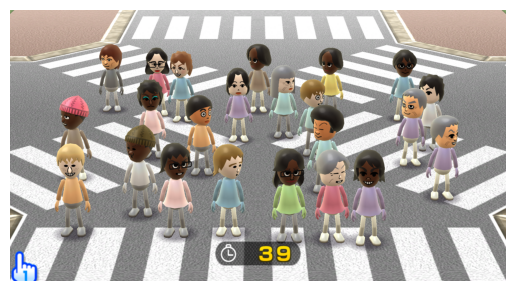

In [15]:
# Load the image (OpenCV loads images in BGR by default, so we need to convert it to RGB)
img = cv2.imread('test_5.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Display the image using Matplotlib
plt.imshow(img_rgb)
plt.axis('off')  # Hides the axis for better visibility
plt.show()

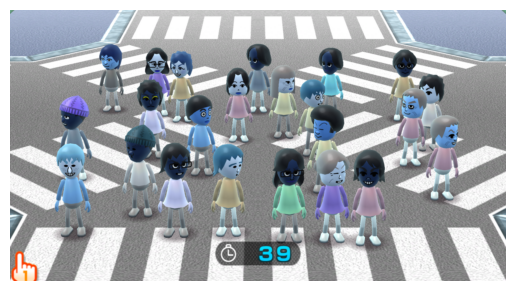

In [14]:
# Apply Gaussian Blur to smooth out noise
img = cv2.GaussianBlur(img, (5, 5), 0)

plt.imshow(img)
plt.axis('off')  # Hides the axis for better visibility
plt.show()

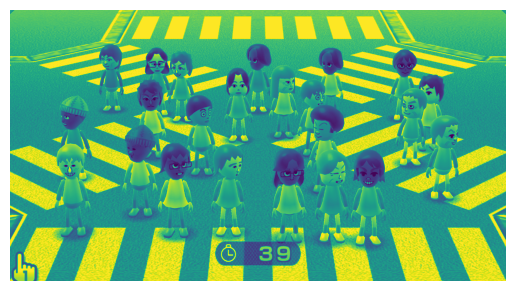

In [12]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)
plt.axis('off')  # Hides the axis for better visibility
plt.show()

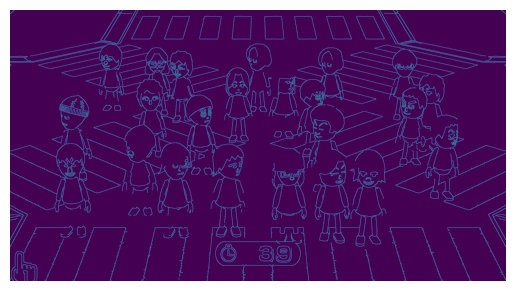

In [5]:
img = cv2.Canny(img, 100, 200)

plt.imshow(img)
plt.axis('off')  # Hides the axis for better visibility
plt.show()

In [45]:
params = cv2.SimpleBlobDetector_Params()
detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(img)

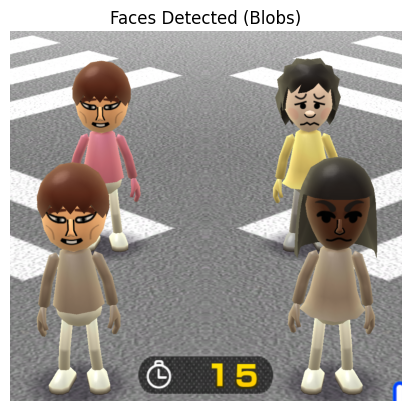

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('test_1.png')

# Convert the image to grayscale (necessary for blob detection)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Set up the SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Filter by Area
params.filterByArea = True
params.minArea = 100

# Filter by Circularity (optional, to detect face-like circular shapes)
params.filterByCircularity = True
params.minCircularity = 0.5

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.87

# Filter by Inertia (to detect round blobs like faces)
params.filterByInertia = True
params.minInertiaRatio = 0.5

# Create a detector with the above parameters
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(gray_img)

# Draw detected blobs as red circles on the original image
im_with_keypoints = cv2.drawKeypoints(img, keypoints, np.array([]), (0, 0, 255), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Convert the image from BGR (OpenCV's default color format) to RGB (Matplotlib's expected format)
im_with_keypoints_rgb = cv2.cvtColor(im_with_keypoints, cv2.COLOR_BGR2RGB)

# Display the image with Matplotlib
plt.imshow(im_with_keypoints_rgb)
plt.axis('off')  # Hide the axis
plt.title("Faces Detected (Blobs)")
plt.show()


In [24]:
import cv2
import os

# Function to segment the Miis from a screenshot after resizing it
def segment_miis(image_path, grid_size=(39, 21), output_dir="segmented_miis", target_size=None, resize_dims=(1920, 1050)):
    """
    Segments Miis from a grid screenshot after resizing.

    :param image_path: Path to the screenshot image.
    :param grid_size: Tuple representing number of rows and columns of Miis in the grid.
    :param output_dir: Directory to save the segmented Miis.
    :param target_size: Size to resize each Mii image. If None, keep original size.
    :param resize_dims: Tuple representing new dimensions to resize the image before segmentation.
    """
    # Load the image
    image = cv2.imread(image_path)
    print(f"Original image size: {image.shape[1]}x{image.shape[0]}")

    # Resize the image
    resized_image = cv2.resize(image, resize_dims)
    h, w, _ = resized_image.shape
    print(f"Resized image to: {w}x{h}")

    # Calculate grid cell size
    cell_h, cell_w = h // grid_size[1], w // grid_size[0]  # 21 vertical, 39 horizontal
    print(f"Each grid cell size: {cell_w}x{cell_h}")

    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Segment each Mii from the grid
    mii_count = 0
    for i in range(grid_size[1]):  # Loop over rows (21 vertical segments)
        for j in range(grid_size[0]):  # Loop over columns (39 horizontal segments)
            # Crop the region corresponding to this Mii
            mii_image = resized_image[i * cell_h:(i + 1) * cell_h, j * cell_w:(j + 1) * cell_w]

            # Resize if a target size is provided
            if target_size:
                mii_image = cv2.resize(mii_image, target_size)

            # Save the cropped Mii image
            mii_filename = os.path.join(output_dir, f"mii_{mii_count}.png")
            cv2.imwrite(mii_filename, mii_image)
            mii_count += 1

    print(f"Segmented and saved {mii_count} Miis to {output_dir}.")

# Example usage
image_path = 'test_5.png'  # Path to the original screenshot
segment_miis(image_path, grid_size=(15, 8), resize_dims=(960, 525))  # Resizing to 1920x1050 before segmenting


Original image size: 2501x1368
Resized image to: 960x525
Each grid cell size: 64x65
Segmented and saved 120 Miis to segmented_miis.
